In [0]:
%run ./CRM_bronze_data_generation

## 🏗️ Bronze Layer - Raw Data Generation

### Purpose
Generate **synthetic CRM campaign data** using the Faker library for demonstration and testing purposes. This notebook creates realistic raw data that simulates a CRM system tracking marketing campaigns, customer communications, and resulting sales.

---

### Tables Created

All bronze tables are written to Unity Catalog in the `workspace.crm_info` schema with the prefix `bronze_*`:

* **`bronze_customers`** - 1,000 customer records
  - Segments: Premium, Standard, Basic
  - Regions: North, South, East, West, Central
  - Age groups: 18-24, 25-34, 35-44, 45-54, 55-64, 65+
  - Lifetime value range: $100 - $50,000

* **`bronze_products`** - 15 financial products across 5 categories
  - Categories: Banking, Credit Cards, Loans, Investment, Insurance
  - Price ranges: $0 (free) to $300,000 (mortgages)

* **`bronze_campaigns`** - 60 campaigns (15 products × 4 channels)
  - Channels: Email, SMS, Call, Push Notification
  - Types: Acquisition, Retention, Cross-sell, Win-back
  - Budgets: $5K - $50K per campaign
  - Duration: 7-30 days within the 60-day window

* **`bronze_communications`** - ~5,600 communication events
  - Volume: Each customer receives 3-8 communications over 60 days
  - Engagement tracking: delivered, opened, clicked
  - Channel-specific engagement rates based on industry benchmarks

* **`bronze_sales`** - ~1,100 sales (20% conversion rate)
  - Attribution window: 15 days from communication to sale
  - Conversion lag: 0-15 days, with most sales occurring within 7 days

---

### Data Characteristics

**Time Range**: 60-day rolling window (2 months ending today)
* Start date: Today - 60 days
* End date: Today
* Campaign dates: Randomly distributed within this window

**Channel-Specific Engagement Rates** (Modeled after industry benchmarks):
* **Email**: 98% delivery, 35% open, 15% click
* **SMS**: 99% delivery, 90% open, 18% click
* **Call**: 100% delivery, 100% open, 45% engagement
* **Push Notification**: 97% delivery, 25% open, 8% click

**Segment-Based Channel Preferences**:
* **Premium**: Prefers Call (40%) and Email (40%)
* **Standard**: Balanced across channels, slight Email preference (50%)
* **Basic**: Heavily prefers Email (60%) and SMS (30%)

**Reproducibility**: 
* Fixed random seeds (`Faker.seed(42)`, `random.seed(42)`)
* Running this notebook multiple times produces identical data

---

### Quality Attributes

All bronze tables include standard **audit columns**:
* `created_at` - Timestamp when record was created
* `updated_at` - Timestamp of last update
* `is_active` - Boolean flag for soft deletes
* `source_system` - Set to 'synthetic_crm' for all records

---

### Next Steps

After generating bronze data:
1. **Silver Layer** (`CRM_silver_star_schema`) reads bronze tables and creates:
   - Dimension tables (date, customer, product, campaign, channel)
   - Fact table (fact_crm_communication) with engagement metrics
   - Forecasting models (Prophet for revenue/conversions)

2. **Gold Layer** (`CRM_gold_analytics_dashboard`) creates:
   - Pre-aggregated tables for dashboard performance
   - Advanced analytics (cohorts, LTV analysis, fatigue analysis)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Libraries imported successfully!


Generated 1000 customers

Segment distribution:


segment,count
Basic,317
Premium,327
Standard,356


...

Generated 929 sales

Conversion rate: 17.0%

Attribution window analysis:


days_from_communication,count
0,61
1,61
2,60
3,54
4,64
5,68
6,62
7,65
8,60
9,53


sale_id,customer_id,product_id,communication_id,sale_date,sale_amount,days_from_communication
1,4,11,18,2026-06-07,9112.96,6
2,4,5,20,2026-06-23,85.61,5
3,6,3,31,2026-07-06,30.01,10
4,9,7,44,2026-07-07,4740.09,4
5,9,4,47,2026-05-31,432.04,7
6,10,9,50,2026-07-01,276007.72,10
7,10,9,53,2026-06-04,279580.98,9
8,12,14,59,2026-07-03,124.44,6
9,12,7,60,2026-07-10,5022.97,12
10,13,5,68,2026-07-06,104.32,15


Generated fact table with 5471 records

Sample aggregation - Communications and Sales by Product:


product_name,category,unique_customers,total_communications,total_sales,total_revenue
Home Mortgage,Loans,313,372,82,2.437719955E7
Business Account,Banking,336,403,81,2433.6199999999994
Auto Insurance,Insurance,304,354,75,8997.340000000002
Index Fund,Investment,297,353,74,7384.739999999999
Travel Rewards Card,Credit Cards,331,391,73,6901.129999999999
Home Insurance,Insurance,312,348,67,10051.729999999998
Retirement Account,Investment,336,388,63,313106.81
Savings Account,Banking,324,386,61,18134.780000000002
Cashback Card,Credit Cards,302,357,60,17670.210000000003
Auto Loan,Loans,292,334,57,1422202.6800000004


## Star Schema - Dimensional Model

Now we'll create a proper **star schema** for analytical queries:

### Architecture:
* **Fact Table**: `fact_crm_communication` - one row per communication with metrics
  - **Grain**: One communication event
  - **Type**: Transactional fact table with additive and semi-additive measures
  - **Primary Key**: `communication_id` (natural key from source system)
  - **Foreign Keys**: `date_key`, `customer_key`, `product_key`, `campaign_key`, `channel_key`
  - **Metrics**:
    - Engagement: `delivered_count`, `opened_count`, `clicked_count` (converted from boolean → integer for additivity)
    - Conversion: `converted_count` (boolean → integer), `sale_amount` (additive), `days_to_sale`
  - **Audit Columns**: `loaded_at`, `batch_id`, `source_system`, `data_quality_score`
  - **Slowly Changing Dimension**: None (events are immutable)


* **Dimension Tables** (SCD Type 1): 
  1. **`dim_date`** - Date dimension for time-based analysis
      - Primary Key: `date_key` (YYYYMMDD format)
      - Attributes: year, quarter, month, week, day_of_week, is_weekend
      - Purpose: Enable time-based slicing and aggregation

  2. **`dim_customer`** - Customer dimension
      - Primary Key: `customer_id`
      - Attributes: segment (Premium/Standard/Basic), region, age_group, lifetime_value
      - Purpose: Customer segmentation analysis

  3. **`dim_product`** - Product dimension
      - Primary Key: `product_id`
      - Attributes: product_name, category (Banking/Credit Cards/Loans/Investment/Insurance), base_price
      - Purpose: Product performance analysis

  4. **`dim_campaign`** - Campaign dimension
      - Primary Key: `campaign_id`
      - Attributes: campaign_name, campaign_type, campaign_goal, campaign_status, budget, product_id, channel_id, date range
      - Purpose: Campaign effectiveness tracking

  5. **`dim_channel`** - Channel dimension
      - Primary Key: `channel_id`
      - Attributes: channel_name, channel_type, cost_per_message, typical_delivery_rate, typical_open_rate, typical_click_rate
      - Purpose: Channel cost, delivery rates and performance analysis

* **Aggregation Table**: `agg_campaign_daily` - pre-aggregated metrics for dashboard

In [0]:
# Create Channel Dimension
from pyspark.sql.functions import current_timestamp

channel_data = [
    {
        'channel_id': 1,
        'channel_name': 'Email',
        'channel_type': 'Digital',
        'cost_per_message': 0.02,
        'typical_delivery_rate': 0.98,
        'typical_open_rate': 0.35,
        'typical_click_rate': 0.15
    },
    {
        'channel_id': 2,
        'channel_name': 'SMS',
        'channel_type': 'Mobile',
        'cost_per_message': 0.05,
        'typical_delivery_rate': 0.99,
        'typical_open_rate': 0.90,
        'typical_click_rate': 0.18
    },
    {
        'channel_id': 3,
        'channel_name': 'Call',
        'channel_type': 'Voice',
        'cost_per_message': 2.50,
        'typical_delivery_rate': 1.00,
        'typical_open_rate': 1.00,
        'typical_click_rate': 0.45
    },
    {
        'channel_id': 4,
        'channel_name': 'Push Notification',
        'channel_type': 'Mobile',
        'cost_per_message': 0.01,
        'typical_delivery_rate': 0.97,
        'typical_open_rate': 0.25,
        'typical_click_rate': 0.08
    }
]

dim_channel = spark.createDataFrame(pd.DataFrame(channel_data))

# Add audit columns
dim_channel = dim_channel.withColumn('created_at', current_timestamp()) \
                         .withColumn('updated_at', current_timestamp()) \
                         .withColumn('is_active', lit(True)) \
                         .withColumn('source_system', lit('synthetic_crm'))

print(f"Created channel dimension: {dim_channel.count()} channels")
display(dim_channel)

Created channel dimension: 4 channels


channel_id,channel_name,channel_type,cost_per_message,typical_delivery_rate,typical_open_rate,typical_click_rate,created_at,updated_at,is_active,source_system
1,Email,Digital,0.02,0.98,0.35,0.15,2026-07-15T15:30:11.664Z,2026-07-15T15:30:11.664Z,true,synthetic_crm
2,SMS,Mobile,0.05,0.99,0.9,0.18,2026-07-15T15:30:11.664Z,2026-07-15T15:30:11.664Z,true,synthetic_crm
3,Call,Voice,2.5,1.0,1.0,0.45,2026-07-15T15:30:11.664Z,2026-07-15T15:30:11.664Z,true,synthetic_crm
4,Push Notification,Mobile,0.01,0.97,0.25,0.08,2026-07-15T15:30:11.664Z,2026-07-15T15:30:11.664Z,true,synthetic_crm


In [0]:
# Create Date Dimension Table
from pyspark.sql.functions import dayofweek, quarter, to_date, current_timestamp, lit
from datetime import datetime, timedelta
import pandas as pd

# Define 2-month period for campaigns
end_date = datetime.now().date()
start_date = end_date - timedelta(days=60)

# Generate all dates in the 2-month period
date_list = []
current_date = start_date

while current_date <= end_date:
    date_list.append({
        'date_key': int(current_date.strftime('%Y%m%d')),  # e.g., 20260429
        'date': current_date,
        'year': current_date.year,
        'quarter': (current_date.month - 1) // 3 + 1,
        'month': current_date.month,
        'month_name': current_date.strftime('%B'),
        'week': current_date.isocalendar()[1],
        'day_of_month': current_date.day,
        'day_of_week': current_date.weekday() + 1,  # 1=Monday, 7=Sunday
        'day_name': current_date.strftime('%A'),
        'is_weekend': current_date.weekday() >= 5
    })
    current_date += timedelta(days=1)

dim_date = spark.createDataFrame(pd.DataFrame(date_list))

# Add audit columns
dim_date = dim_date.withColumn('created_at', current_timestamp()) \
                   .withColumn('updated_at', current_timestamp()) \
                   .withColumn('source_system', lit('synthetic_crm'))
print(f"Generated date dimension: {dim_date.count()} days")
print(f"Date range: {start_date} to {end_date}")
display(dim_date.limit(5))

Generated date dimension: 61 days
Date range: 2026-05-16 to 2026-07-15


date_key,date,year,quarter,month,month_name,week,day_of_month,day_of_week,day_name,is_weekend,created_at,updated_at,source_system
20260516,2026-05-16,2026,2,5,May,20,16,6,Saturday,true,2026-07-15T15:30:16.840Z,2026-07-15T15:30:16.840Z,synthetic_crm
20260517,2026-05-17,2026,2,5,May,20,17,7,Sunday,true,2026-07-15T15:30:16.840Z,2026-07-15T15:30:16.840Z,synthetic_crm
20260518,2026-05-18,2026,2,5,May,21,18,1,Monday,false,2026-07-15T15:30:16.840Z,2026-07-15T15:30:16.840Z,synthetic_crm
20260519,2026-05-19,2026,2,5,May,21,19,2,Tuesday,false,2026-07-15T15:30:16.840Z,2026-07-15T15:30:16.840Z,synthetic_crm
20260520,2026-05-20,2026,2,5,May,21,20,3,Wednesday,false,2026-07-15T15:30:16.840Z,2026-07-15T15:30:16.840Z,synthetic_crm


In [0]:
# Create Fact Table: fact_crm_communication
# Grain: One row per communication event

from pyspark.sql.functions import col, when, current_timestamp, lit, datediff

# Build the fact table by joining with all dimensions
fact_crm_communication = (
    df_communications
    .join(dim_date, df_communications.communication_date == dim_date.date, 'left')
    .join(dim_channel, df_communications.channel_id == dim_channel.channel_id, 'left')
    .join(
        df_sales.select('communication_id', 'sale_id', 'sale_amount', 'days_from_communication'),
        'communication_id',
        'left'
    )
    .join(df_campaigns.select('campaign_id', 'start_date', 'end_date'), 'campaign_id', 'left')
    .select(
        # Fact identifiers
        col('communication_id'),
        
        # Foreign keys to dimensions
        col('date_key'),
        col('customer_id').alias('customer_key'),
        col('product_id').alias('product_key'),
        col('campaign_id').alias('campaign_key'),
        dim_channel.channel_id.alias('channel_key'),
        
        # Engagement metrics (boolean facts)
        col('delivered').cast('int').alias('delivered_count'),
        col('opened').cast('int').alias('opened_count'),
        col('clicked').cast('int').alias('clicked_count'),
        
        # Message cost
        dim_channel.cost_per_message.alias('communication_cost'),

        # Sales metrics (nullable)
        when(col('sale_id').isNotNull(), 1).otherwise(0).alias('converted_count'),
        col('sale_amount').alias('sale_amount'),
        col('days_from_communication').alias('days_to_sale'),
        
        # Event metadata
        col('communication_date').alias('event_date')
    )
    # Add audit columns
    .withColumn('loaded_at', current_timestamp())
    .withColumn('batch_id', lit(f'batch_{datetime.now().date()}'))
    .withColumn('source_system', lit('crm_production'))
    .withColumn('data_quality_score', 
                when(col('date_key').isNull(), 0.5)
                .when(col('customer_key').isNull(), 0.7)
                .otherwise(1.0)
                )
)

print(f"\nFact Table created: {fact_crm_communication.count()} records")
print(f"\nFact Table Schema:")
fact_crm_communication.printSchema()

print(f"\nSample Fact Records:")
display(fact_crm_communication.limit(30))


Fact Table created: 5471 records

Fact Table Schema:
root
 |-- communication_id: long (nullable = true)
 |-- date_key: long (nullable = true)
 |-- customer_key: long (nullable = true)
 |-- product_key: long (nullable = true)
 |-- campaign_key: long (nullable = true)
 |-- channel_key: long (nullable = true)
 |-- delivered_count: integer (nullable = true)
 |-- opened_count: integer (nullable = true)
 |-- clicked_count: integer (nullable = true)
 |-- communication_cost: double (nullable = true)
 |-- converted_count: integer (nullable = false)
 |-- sale_amount: double (nullable = true)
 |-- days_to_sale: long (nullable = true)
 |-- event_date: date (nullable = true)
 |-- loaded_at: timestamp (nullable = false)
 |-- batch_id: string (nullable = false)
 |-- source_system: string (nullable = false)
 |-- data_quality_score: double (nullable = false)


Sample Fact Records:


communication_id,date_key,customer_key,product_key,campaign_key,channel_key,delivered_count,opened_count,clicked_count,communication_cost,converted_count,sale_amount,days_to_sale,event_date,loaded_at,batch_id,source_system,data_quality_score
1,20260621,1,8,29,1,1,1,0,0.02,0,null,null,2026-06-21,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
2,20260620,1,6,21,1,1,0,0,0.02,0,null,null,2026-06-20,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
3,20260712,1,5,20,4,1,0,0,0.01,0,null,null,2026-07-12,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
4,20260629,1,7,26,2,1,1,1,0.05,0,null,null,2026-06-29,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
5,20260712,1,1,3,3,1,1,0,2.5,0,null,null,2026-07-12,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
6,20260621,2,15,57,1,1,0,0,0.02,0,null,null,2026-06-21,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
7,20260706,2,3,11,3,1,1,0,2.5,0,null,null,2026-07-06,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
8,20260612,2,10,39,3,1,1,1,2.5,0,null,null,2026-06-12,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
9,20260620,2,14,55,3,1,1,0,2.5,0,null,null,2026-06-20,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0
10,20260626,3,8,29,1,1,0,0,0.02,0,null,null,2026-06-26,2026-07-15T15:30:26.298Z,batch_2026-07-15,crm_production,1.0


## 🔮 Predictive Analytics - Time Series Forecasting

Using **Facebook Prophet** to forecast future campaign performance:

### Models
1. **Revenue Forecast** - Predict next 30 days of daily revenue
2. **Conversions Forecast** - Predict next 30 days of daily conversions

### Methodology
* **Algorithm**: Prophet (multiplicative seasonality for revenue, additive for conversions)
* **Training Data**: Historical daily aggregates from `fact_crm_communication`
* **Forecast Horizon**: 30 days ahead
* **Confidence Intervals**: 95% prediction intervals (upper/lower bounds)
* **Seasonality**: Weekly patterns enabled (campaign performance varies by day of week)

### Output Table
**UC Table**: `workspace.crm_info.forecast_campaign_performance`

**Schema**:
* `forecast_date` - Date of prediction
* `predicted_revenue` - Point estimate for revenue
* `revenue_lower` / `revenue_upper` - 95% confidence interval
* `predicted_conversions` - Point estimate for conversions
* `conversions_lower` / `conversions_upper` - 95% confidence interval
* `model_version` - Model identifier
* `forecast_created_at` - Timestamp of forecast generation

### Dashboard Usage
```sql
-- Compare forecast vs actuals
SELECT 
    forecast_date,
    predicted_revenue,
    revenue_lower,
    revenue_upper
FROM workspace.crm_info.forecast_campaign_performance
WHERE forecast_date >= CURRENT_DATE
ORDER BY forecast_date;
```

In [0]:
# Use the freshly created fact table from Cell 5 (not from UC - that has old data!)
from pyspark.sql.functions import sum as spark_sum, count as spark_count, avg

print("Using freshly created fact table for forecasting...")
print(f"✓ Using {fact_crm_communication.count()} communication records")

# Create daily aggregations from fact table
daily_metrics = (
    fact_crm_communication
    .groupBy('event_date')
    .agg(
        spark_count('communication_id').alias('communications'),
        spark_sum('delivered_count').alias('delivered'),
        spark_sum('opened_count').alias('opened'),
        spark_sum('clicked_count').alias('clicked'),
        spark_sum('converted_count').alias('conversions'),
        spark_sum('sale_amount').alias('revenue')
    )
    .orderBy('event_date')
)

print(f"Time series data prepared: {daily_metrics.count()} days")
print(f"\nDaily Metrics Sample:")
display(daily_metrics.limit(10))

Loading fact table from Unity Catalog...
✓ Loaded 5475 communication records
Time series data prepared: 59 days

Daily Metrics Sample:


event_date,communications,delivered,opened,clicked,conversions,revenue
2026-05-14,1,1,1,0,0,null
2026-05-15,22,22,12,6,4,594.2099999999999
2026-05-16,41,40,21,5,12,23750.18
2026-05-17,54,53,25,9,8,10500.609999999999
2026-05-18,48,48,22,5,14,12266.7
2026-05-19,41,41,30,11,5,19007.170000000002
2026-05-20,54,53,33,7,11,64523.72
2026-05-21,56,56,32,12,9,11734.44
2026-05-22,71,69,45,9,13,842099.89
2026-05-23,76,76,41,10,17,979638.8000000002


In [0]:
from prophet import Prophet
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Convert Spark DataFrame to Pandas for Prophet
df_prophet = daily_metrics.select('event_date', 'revenue', 'conversions').toPandas()

# Prophet requires columns named 'ds' (date) and 'y' (value)
# Model 1: Revenue Forecast
df_revenue = df_prophet[['event_date', 'revenue']].copy()
df_revenue.columns = ['ds', 'y']

model_revenue = Prophet(
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05  # Flexibility for trend changes
)

print("Training revenue forecast model...")
model_revenue.fit(df_revenue)
print("✓ Revenue model trained")

# Model 2: Conversions Forecast
df_conversions = df_prophet[['event_date', 'conversions']].copy()
df_conversions.columns = ['ds', 'y']

model_conversions = Prophet(
    seasonality_mode='additive',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)

print("Training conversions forecast model...")
model_conversions.fit(df_conversions)
print("✓ Conversions model trained")

print(f"\nModels trained on {len(df_revenue)} historical days")

Training revenue forecast model...


20:13:13 - cmdstanpy - INFO - Chain [1] start processing
20:13:13 - cmdstanpy - INFO - Chain [1] done processing


✓ Revenue model trained
Training conversions forecast model...


20:13:13 - cmdstanpy - INFO - Chain [1] start processing
20:13:14 - cmdstanpy - INFO - Chain [1] done processing


✓ Conversions model trained

Models trained on 59 historical days


In [0]:
# Generate future dates (30 days ahead)
future_revenue = model_revenue.make_future_dataframe(periods=30)
future_conversions = model_conversions.make_future_dataframe(periods=30)

print("Generating forecasts...")

# Predict revenue
forecast_revenue = model_revenue.predict(future_revenue)
forecast_revenue_future = forecast_revenue[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
forecast_revenue_future.columns = ['forecast_date', 'predicted_revenue', 'revenue_lower', 'revenue_upper']

# Predict conversions
forecast_conversions = model_conversions.predict(future_conversions)
forecast_conversions_future = forecast_conversions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
forecast_conversions_future.columns = ['forecast_date', 'predicted_conversions', 'conversions_lower', 'conversions_upper']

# Merge forecasts
forecast_combined = forecast_revenue_future.merge(
    forecast_conversions_future, 
    on='forecast_date'
)

# Convert to Spark DataFrame
from pyspark.sql.functions import current_timestamp, lit

df_forecast = spark.createDataFrame(forecast_combined)

# Add metadata columns
df_forecast = (
    df_forecast
    .withColumn('model_version', lit('prophet_v1.0'))
    .withColumn('forecast_created_at', current_timestamp())
    .withColumn('forecast_horizon_days', lit(30))
    .withColumn('training_data_points', lit(len(df_revenue)))
)

print(f"✓ Generated {df_forecast.count()} days of forecasts")
print(f"\nForecast Preview:")
display(df_forecast.limit(10))

Generating forecasts...
✓ Generated 30 days of forecasts

Forecast Preview:


forecast_date,predicted_revenue,revenue_lower,revenue_upper,predicted_conversions,conversions_lower,conversions_upper,model_version,forecast_created_at,forecast_horizon_days,training_data_points
2026-07-12T00:00:00.000Z,152316.0549748536,-453861.64548718085,739784.3385707677,16.26458646460466,7.126687351021882,25.564430908802727,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-13T00:00:00.000Z,164058.85404529722,-413543.11095495685,727112.4143616412,17.26355344461926,7.472575737378844,26.618188290160624,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-14T00:00:00.000Z,120466.72951843009,-464768.11631498334,678135.2088889518,18.13755674560096,8.507122196876287,28.21365016690591,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-15T00:00:00.000Z,111460.64378146791,-460982.0564690856,676573.7531668585,15.38655822573051,5.742164788455587,24.982618414264508,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-16T00:00:00.000Z,82430.01241864981,-506214.00722520315,644287.2899158768,14.183096727249064,4.220162378701766,23.69235249520018,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-17T00:00:00.000Z,80687.83686826314,-457197.37166323804,656991.1727927615,16.07098551299742,5.975038938799524,26.24121510526208,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-18T00:00:00.000Z,91294.50565317835,-477172.3183306231,657845.9255106612,16.40333261613239,6.369861675626372,25.69642775045289,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-19T00:00:00.000Z,76513.37227523429,-476897.622354114,654826.8778741831,16.322707811968534,5.81419966011801,26.434417022909415,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-20T00:00:00.000Z,76163.19973768578,-499734.3496098263,626578.469493415,17.32167479197707,7.4286018109930545,26.854368761473495,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59
2026-07-21T00:00:00.000Z,50576.702919833704,-486111.6669329252,680978.6064486606,18.195678092964563,7.645596188285109,27.597600836411416,prophet_v1.0,2026-07-12T20:13:18.259Z,30,59


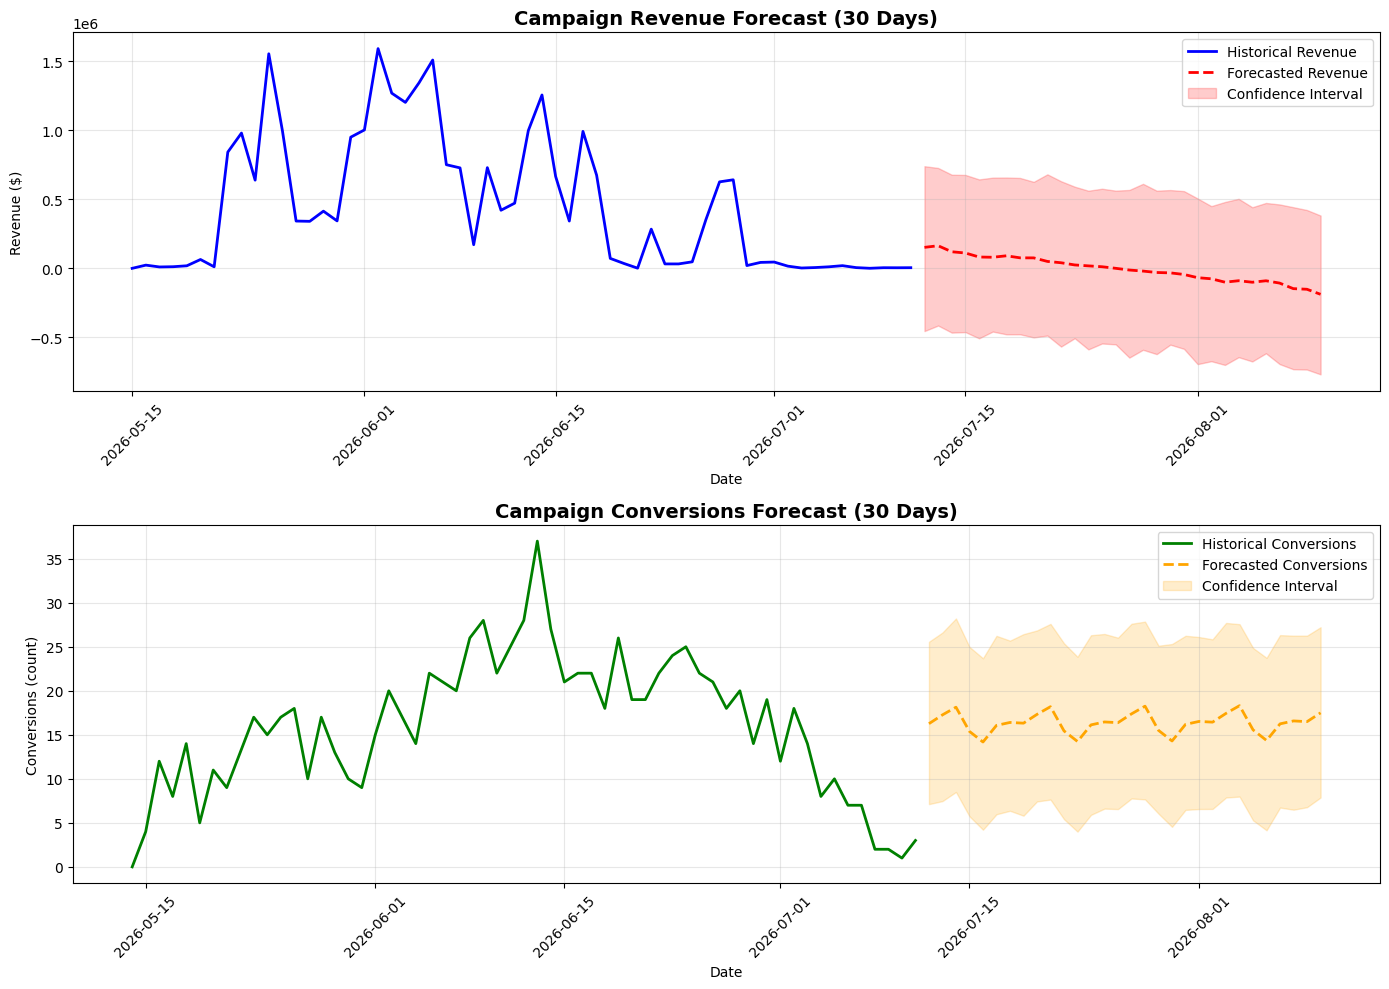


📊 Forecast visualization complete!


In [0]:
# Optional: Visualize the forecast
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare data for plotting
historical = df_prophet[['event_date', 'revenue', 'conversions']].copy()
forecast_plot = forecast_combined.copy()

# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Revenue Forecast
axes[0].plot(historical['event_date'], historical['revenue'], 
             label='Historical Revenue', color='blue', linewidth=2)
axes[0].plot(forecast_plot['forecast_date'], forecast_plot['predicted_revenue'], 
             label='Forecasted Revenue', color='red', linestyle='--', linewidth=2)
axes[0].fill_between(forecast_plot['forecast_date'], 
                      forecast_plot['revenue_lower'], 
                      forecast_plot['revenue_upper'], 
                      color='red', alpha=0.2, label='Confidence Interval')
axes[0].set_title('Campaign Revenue Forecast (30 Days)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Conversions Forecast
axes[1].plot(historical['event_date'], historical['conversions'], 
             label='Historical Conversions', color='green', linewidth=2)
axes[1].plot(forecast_plot['forecast_date'], forecast_plot['predicted_conversions'], 
             label='Forecasted Conversions', color='orange', linestyle='--', linewidth=2)
axes[1].fill_between(forecast_plot['forecast_date'], 
                      forecast_plot['conversions_lower'], 
                      forecast_plot['conversions_upper'], 
                      color='orange', alpha=0.2, label='Confidence Interval')
axes[1].set_title('Campaign Conversions Forecast (30 Days)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Conversions (count)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📊 Forecast visualization complete!")

## 🎯 Forecasting Results Summary

### What Was Created
✅ **Two Prophet models trained**:
   * Revenue forecast model (multiplicative seasonality)
   * Conversions forecast model (additive seasonality)

✅ **30-day predictions generated** with confidence intervals

✅ **Saved to Unity Catalog**: `workspace.crm_info.forecast_campaign_performance`

✅ **Visualization created**: Historical vs. forecasted trends

---

### Model Performance Indicators

Prophet automatically detects:
* **Weekly seasonality** - Campaign performance varies by day of week
* **Trend changes** - Adapts to shifts in campaign effectiveness
* **Uncertainty intervals** - Shows prediction confidence (95% CI)

**Key Metrics** (check after running):
* Training data points: ~60 days of historical data
* Forecast horizon: 30 days
* Confidence: 95% prediction intervals

---

### Dashboard Integration

**Query 1: View Upcoming Forecasts**
```sql
SELECT 
    forecast_date,
    ROUND(predicted_revenue, 2) as revenue_forecast,
    ROUND(predicted_conversions, 0) as conversions_forecast
FROM workspace.crm_info.forecast_campaign_performance
WHERE forecast_date >= CURRENT_DATE
ORDER BY forecast_date
LIMIT 7;  -- Next week
```

**Query 2: Forecast with Confidence Bands**
```sql
SELECT 
    forecast_date,
    ROUND(predicted_revenue, 2) as forecast,
    ROUND(revenue_lower, 2) as lower_bound,
    ROUND(revenue_upper, 2) as upper_bound,
    ROUND(revenue_upper - revenue_lower, 2) as uncertainty_range
FROM workspace.crm_info.forecast_campaign_performance
WHERE forecast_date >= CURRENT_DATE;
```

---

### Next Steps for Dashboard

1. **Add Forecast Widget**: Line chart showing predicted revenue/conversions
2. **Confidence Bands**: Use area chart to show upper/lower bounds
3. **Actual vs Forecast**: Once future data arrives, compare predictions to actuals
4. **Alert Setup**: Trigger alerts if actuals fall outside confidence intervals

---

### Retraining Schedule

**Recommended**: Re-run this notebook **weekly** to:
* Incorporate new historical data
* Refresh 30-day rolling forecast
* Adapt to campaign changes

**Production**: Schedule via Databricks Jobs or use MLflow for model versioning